In [1]:
!pip install geopandas
!pip install contextily
!pip install mapclassify
!pip install "folium>=0.12"
import math
import os
from tabulate import tabulate
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import math
import contextily as cx
import mapclassify

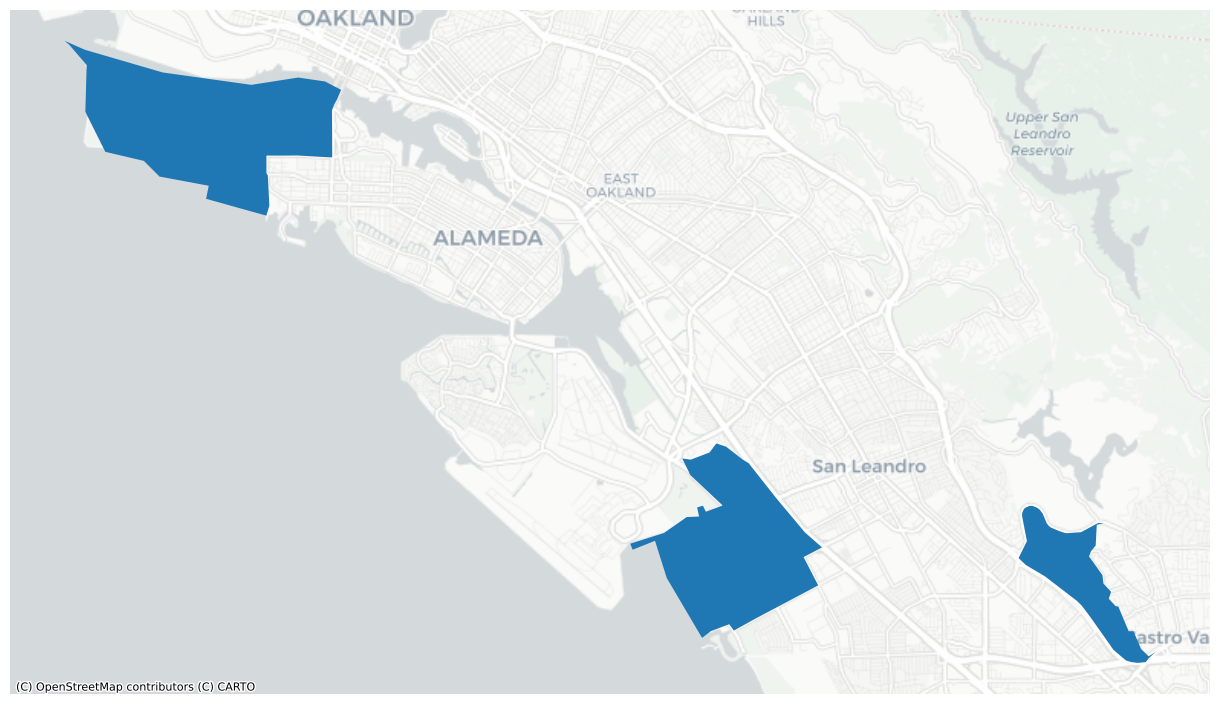

In [8]:
tract_a = gpd.read_file("../data/alameda_epc.geojson")
tract_sl = gpd.read_file("../data/san_leandro_epc.geojson")
tract_cv = gpd.read_file("../data/castro_valley_epc.geojson")
combined_boundary = pd.concat([tract_a, tract_sl, tract_cv], ignore_index=True)
tract_a = tract_a.to_crs(3857)
tract_sl = tract_sl.to_crs(3857)
tract_cv = tract_cv.to_crs(3857)
combined_boundary = combined_boundary.to_crs(3857)

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
combined_boundary.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

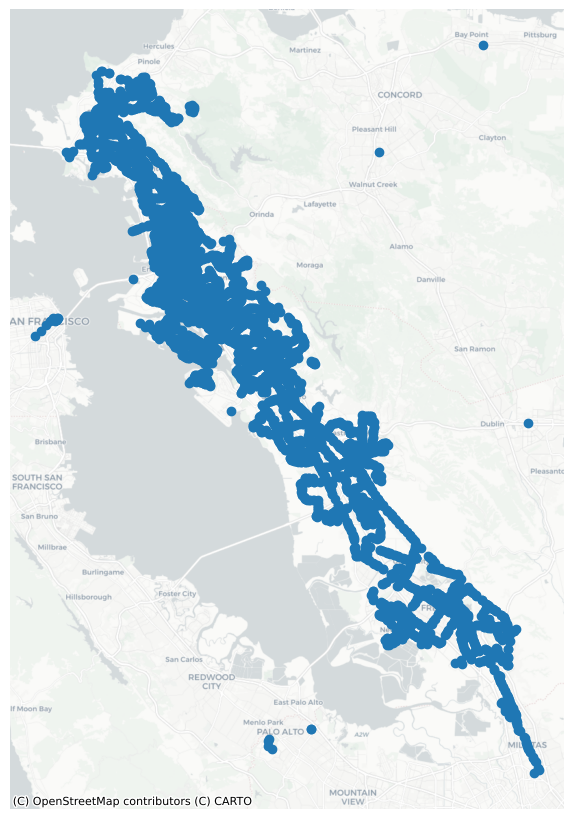

In [9]:
bus = pd.read_csv("../data/actransit_gtfs.csv")
bus_gdf = gpd.GeoDataFrame(
    bus, 
    geometry=gpd.points_from_xy(bus['stop_lon'], bus['stop_lat'], 
    crs = 4326)
    )
bus_gdf = bus_gdf.to_crs(3857)
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
bus_gdf.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

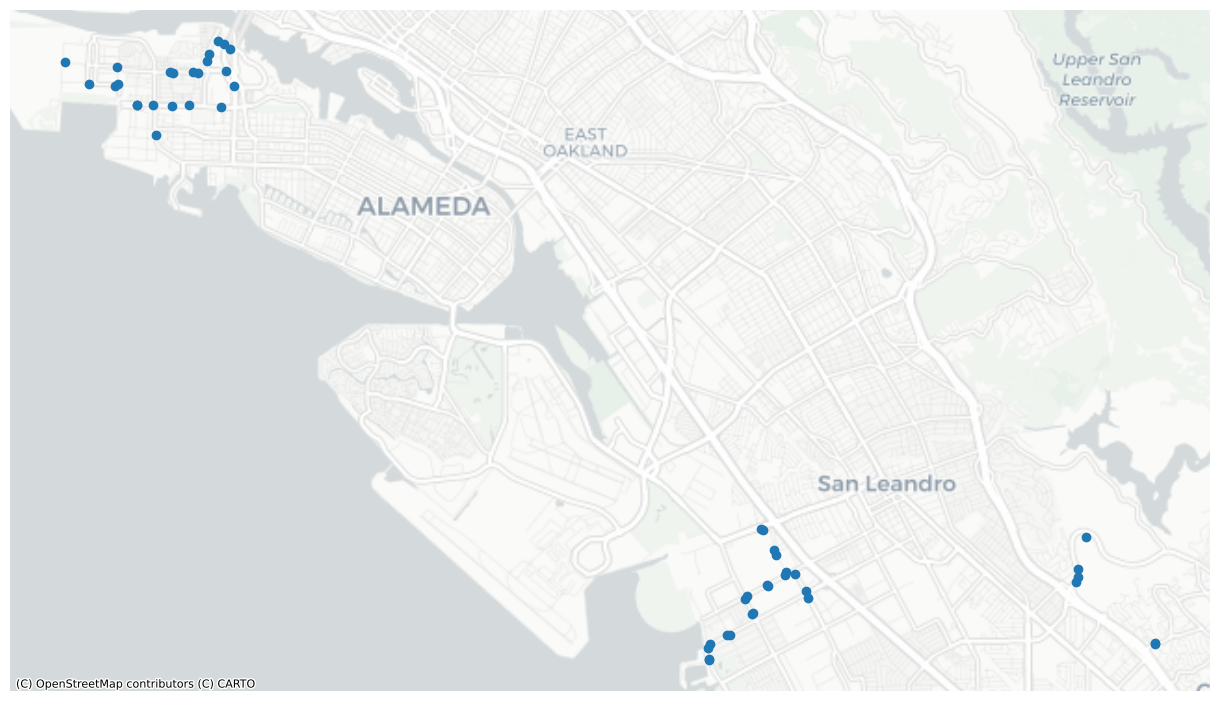

In [10]:
'''
replace combined_boundary with whichever tract you want to filter for only those buses
Options are:
tract_a
tract_sl
tract_cv
'''
clipped_buses = gpd.clip(bus_gdf,combined_boundary)
fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])
clipped_buses.plot(ax=ax)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()